In [14]:
import matplotlib.pyplot as plt
import h5py

import numpy as np
from matplotlib import ticker, font_manager
import warnings
warnings.filterwarnings("ignore")
def ticks_figure(ax):
    ax.xaxis.set_tick_params(width=1,length=8)
    ax.yaxis.set_tick_params(width=1,length=8)
    ax.xaxis.set_tick_params(which='minor',width=1,length=4)
    ax.yaxis.set_tick_params(which='minor',width=1,length=4)
    ax.xaxis.set_tick_params(tickdir="in", left="True",labelleft="True",right="True")
    ax.yaxis.set_tick_params(tickdir="in", left="True",labelleft="True",right="True")
    ax.xaxis.set_tick_params(tickdir="in", left="True",which='minor',labelleft="True",right="True")
    ax.yaxis.set_tick_params(tickdir="in", left="True",which='minor',labelleft="True",right="True")
    ax.minorticks_on()
    return

In [15]:
def my_interp2d(f, rad, radnew):
    import numpy as np
    import scipy.interpolate as inp
    r = rad
    rnew = radnew
    fnew = np.zeros_like(f)
    for i in range(f.shape[0]):
        val = f[i, :]
        tckp = inp.splrep(r, val)
        fnew[i, :] = inp.splev(rnew, tckp)

    return fnew
    
def plot_stream(r,theta,vr_n,vtheta_n,density,label=None,clim=[0,0]):

    rad = np.linspace(r[-1], r[0], len(r))
    theta = np.linspace(0,np.pi,len(theta))

    rr, ttheta = np.meshgrid(rad, theta)
    plt.figure()
    fig,ax = plt.subplots(1,1,figsize=(6,6),subplot_kw={'projection': 'polar'})

    un = vr_n[:,::-1]
    vn = vtheta_n[:,::-1]/rr[:,::-1]

    un = my_interp2d(un, r[::-1], rad)
    vn = my_interp2d(vn, r[::-1], rad)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rorigin(0)
    ax.set_ylim(r.min(),r.max())
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    strm = ax.streamplot(ttheta.T,rr.T,vn.T,un.T,color='#d95f02',density=density,
                         broken_streamlines=True,linewidth=1)

    fig.tight_layout()
    

(100, 128, 64, 128)


Text(0.5, 1.0, '$t =$10.2')

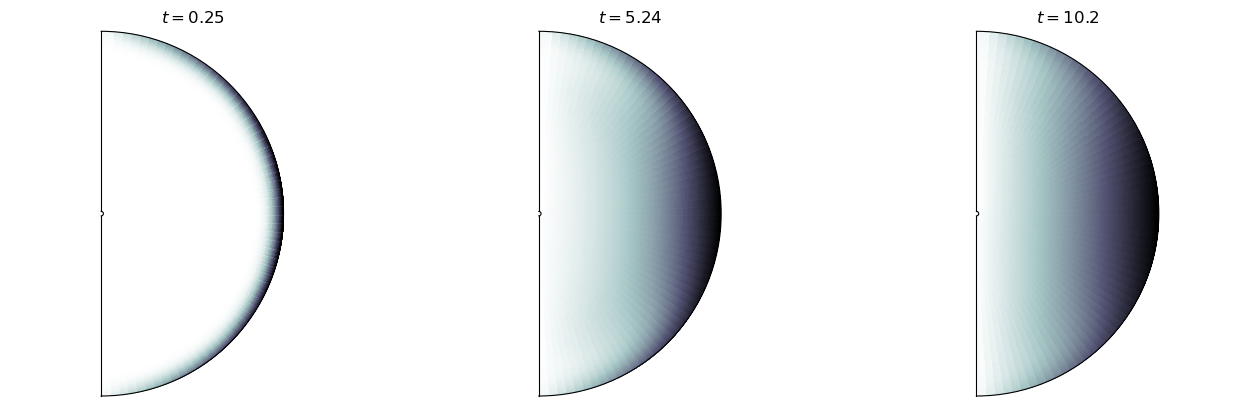

In [16]:
Delta_Omega=0.001

fig,ax = plt.subplots(1,3,figsize=(16,8),subplot_kw={'projection': 'polar'})

dire = './AZ_avg/AZ_avg_s1.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']
print(np.shape(u_n_phi))    
time = np.array(data['scales/sim_time'])  
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

j = 10

u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[0].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[0].set_theta_zero_location('N')
ax[0].set_theta_direction(-1)
ax[0].set_rorigin(0)
ax[0].set_ylim(r.min(),r.max())
ax[0].set_thetamin(0)
ax[0].set_thetamax(180)
ax[0].grid(False)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title(r'$t =$'+str(time[j])[:4])


dire = './AZ_avg/AZ_avg_s3.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[1].set_rorigin(0)
ax[1].set_ylim(r.min(),r.max())
ax[1].set_thetamin(0)
ax[1].set_thetamax(180)
ax[1].grid(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title(r'$t =$'+str(time[j])[:4])

dire = './AZ_avg/AZ_avg_s5.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[2].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[2].set_theta_zero_location('N')
ax[2].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])


Text(0.5, 1.0, '$t =$12.7')

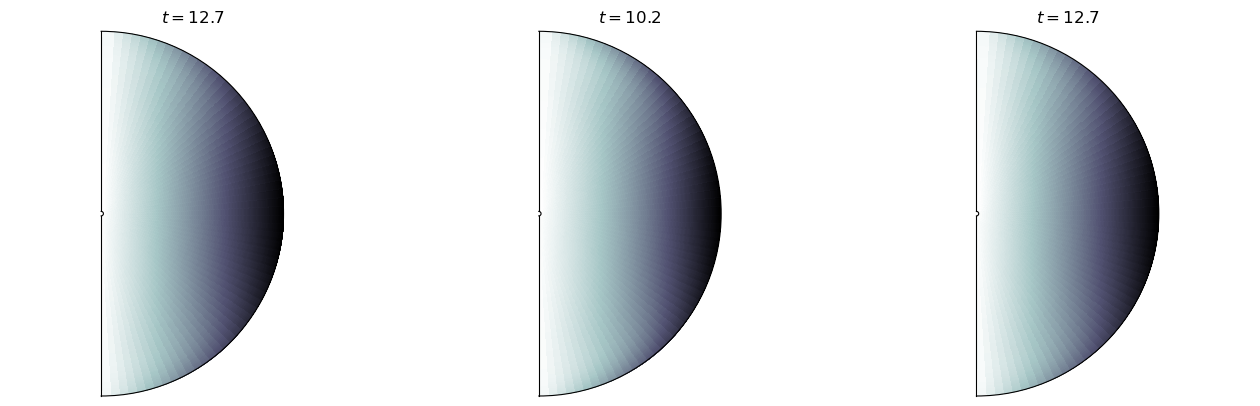

In [17]:
Delta_Omega=0.001

fig,ax = plt.subplots(1,3,figsize=(16,8),subplot_kw={'projection': 'polar'})

dire = './AZ_avg/AZ_avg_s6.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

j = 10

u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[0].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[0].set_theta_zero_location('N')
ax[0].set_theta_direction(-1)
ax[0].set_rorigin(0)
ax[0].set_ylim(r.min(),r.max())
ax[0].set_thetamin(0)
ax[0].set_thetamax(180)
ax[0].grid(False)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title(r'$t =$'+str(time[j])[:4])


dire = './AZ_avg/AZ_avg_s5.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[1].set_rorigin(0)
ax[1].set_ylim(r.min(),r.max())
ax[1].set_thetamin(0)
ax[1].set_thetamax(180)
ax[1].grid(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title(r'$t =$'+str(time[j])[:4])

dire = './AZ_avg/AZ_avg_s6.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[2].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[2].set_theta_zero_location('N')
ax[2].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])

Text(0.5, 1.0, '$t =$10.1')

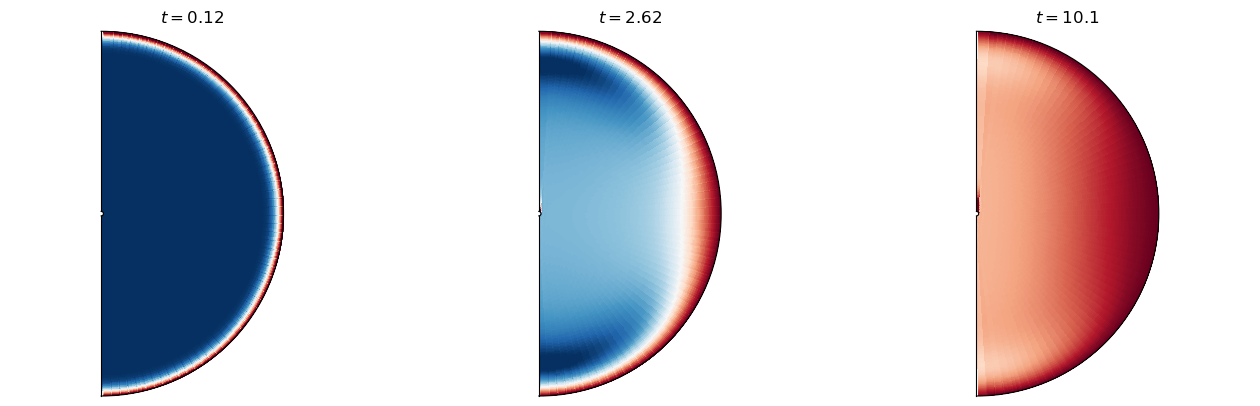

In [21]:
Delta_Omega=0.001
cmap = 'RdBu_r'

fig,ax = plt.subplots(1,3,figsize=(16,8),subplot_kw={'projection': 'polar'})

dire = './AZ_avg/AZ_avg_s1.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

j = 5

u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[0].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap=cmap,edgecolors='face')
ax[0].set_theta_zero_location('N')
ax[0].set_theta_direction(-1)
ax[0].set_rorigin(0)
ax[0].set_ylim(r.min(),r.max())
ax[0].set_thetamin(0)
ax[0].set_thetamax(180)
ax[0].grid(False)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title(r'$t =$'+str(time[j])[:4])


dire = './AZ_avg/AZ_avg_s2.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap=cmap,edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[1].set_rorigin(0)
ax[1].set_ylim(r.min(),r.max())
ax[1].set_thetamin(0)
ax[1].set_thetamax(180)
ax[1].grid(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title(r'$t =$'+str(time[j])[:4])

dire = './AZ_avg/AZ_avg_s5.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[2].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap=cmap,edgecolors='face')
ax[2].set_theta_zero_location('N')
ax[2].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])

TypeError: 'PolarAxes' object is not subscriptable

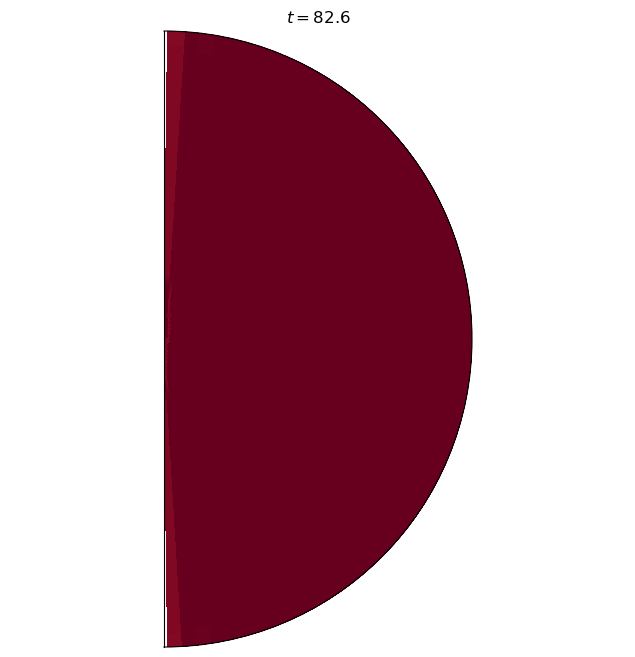

In [19]:
dire = './AZ_avg/AZ_avg_s34.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]
fig,ax = plt.subplots(1,1,figsize=(16,8),subplot_kw={'projection': 'polar'})


#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax.pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap='RdBu_r',edgecolors='face')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetamin(0)
ax.set_thetamax(180)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(r'$t =$'+str(time[j])[:4])

ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])


In [ ]:
u_n_phi.shape

(64, 128)

In [ ]:
omega

array([[0.00868271, 0.00433191, 0.00294794, ..., 0.00095985, 0.00095985,
        0.00095986],
       [0.00384038, 0.00199653, 0.0014453 , ..., 0.00100243, 0.00100239,
        0.00100237],
       [0.00251563, 0.00139706, 0.00110082, ..., 0.00099546, 0.00099546,
        0.00099546],
       ...,
       [0.00251563, 0.00139706, 0.00110082, ..., 0.00099546, 0.00099546,
        0.00099546],
       [0.00384038, 0.00199653, 0.0014453 , ..., 0.00100243, 0.00100239,
        0.00100237],
       [0.00868271, 0.00433191, 0.00294794, ..., 0.00095985, 0.00095985,
        0.00095986]], shape=(64, 128))

<Figure size 640x480 with 0 Axes>

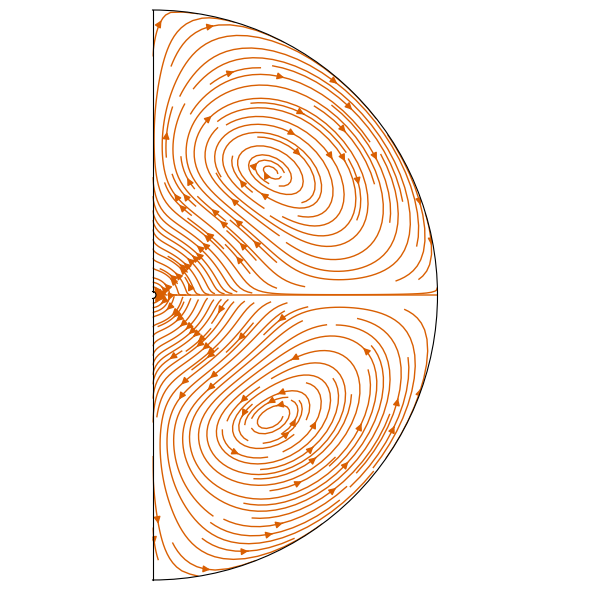

In [20]:
density = 2

dire = './AZ_avg/AZ_avg_s3.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
phi = u_n_phi.dims[1][0][:].ravel()
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

u_n_r = data['tasks']['u_n_r'][:,-1,:,:]
u_n_theta = data['tasks']['u_n_theta'][:,-1,:,:]

j=-1
plot_stream(r[::-1],theta,u_n_r[j],u_n_theta[j],density=density,label=None,clim=[0,0])


In [ ]:
omega.shape

(64, 128)

In [ ]:
r.shape

(128,)

In [ ]:
theta.shape

(64,)

In [ ]:
r_m.shape

(64, 128)

In [ ]:
theta

array([3.10430891, 3.0560109 , 3.00742767, 2.95878   , 2.91010788,
       2.86142394, 2.81273339, 2.76403877, 2.71534148, 2.66664234,
       2.61794187, 2.5692404 , 2.52053817, 2.47183536, 2.42313207,
       2.37442841, 2.32572444, 2.27702021, 2.22831578, 2.17961117,
       2.13090641, 2.08220153, 2.03349654, 1.98479146, 1.93608631,
       1.88738109, 1.83867583, 1.78997052, 1.74126518, 1.69255981,
       1.64385442, 1.59514903, 1.54644363, 1.49773823, 1.44903285,
       1.40032748, 1.35162214, 1.30291683, 1.25421156, 1.20550635,
       1.15680119, 1.10809611, 1.05939113, 1.01068624, 0.96198148,
       0.91327687, 0.86457244, 0.81586821, 0.76716424, 0.71846058,
       0.6697573 , 0.62105448, 0.57235225, 0.52365078, 0.47495031,
       0.42625117, 0.37755388, 0.32885927, 0.28016871, 0.23148477,
       0.18281265, 0.13416498, 0.08558175, 0.03728374])

In [ ]:
r

array([0.01220003, 0.02439825, 0.03659284, 0.04878198, 0.06096386,
       0.07313666, 0.08529858, 0.0974478 , 0.10958252, 0.12170093,
       0.13380122, 0.14588159, 0.15794025, 0.16997541, 0.18198526,
       0.19396802, 0.20592192, 0.21784516, 0.22973597, 0.24159259,
       0.25341325, 0.2651962 , 0.27693966, 0.28864191, 0.30030119,
       0.31191577, 0.32348393, 0.33500393, 0.34647407, 0.35789264,
       0.36925794, 0.38056828, 0.39182197, 0.40301734, 0.41415272,
       0.42522645, 0.43623689, 0.4471824 , 0.45806135, 0.46887211,
       0.47961309, 0.49028267, 0.50087928, 0.51140134, 0.52184727,
       0.53221553, 0.54250457, 0.55271286, 0.56283888, 0.57288113,
       0.5828381 , 0.59270832, 0.60249031, 0.61218263, 0.62178383,
       0.63129247, 0.64070715, 0.65002646, 0.65924902, 0.66837345,
       0.67739839, 0.68632251, 0.69514447, 0.70386296, 0.71247668,
       0.72098435, 0.7293847 , 0.73767649, 0.74585848, 0.75392945,
       0.76188819, 0.76973354, 0.77746431, 0.78507936, 0.79257

In [ ]:
omega[:, -1].shape

(64,)

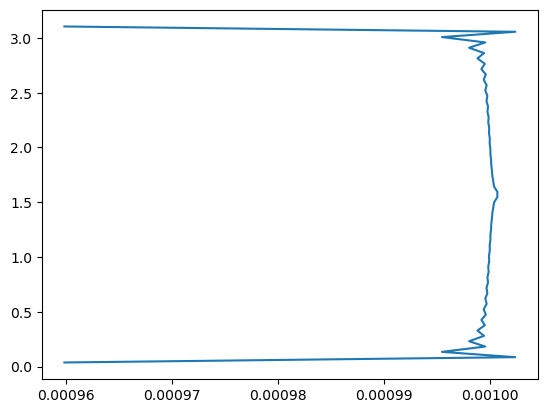

In [ ]:
plt.plot(omega[:, -1], theta)

plt.show()

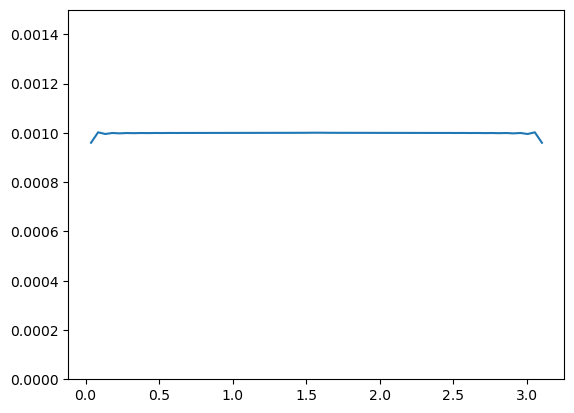

In [ ]:
fig, ax = plt.subplots()
ax.plot(theta, omega[:, -1])

ax.set_ylim(0, 1.5e-3)

plt.show()

In [ ]:
np.pi/2

1.5707963267948966

In [ ]:
theta.shape

(64,)

In [ ]:
theta[31]

np.float64(1.5951490264645276)

In [ ]:
omega[31, -1]

np.float64(0.0010006807322428396)

In [ ]:
r

array([0.01220003, 0.02439825, 0.03659284, 0.04878198, 0.06096386,
       0.07313666, 0.08529858, 0.0974478 , 0.10958252, 0.12170093,
       0.13380122, 0.14588159, 0.15794025, 0.16997541, 0.18198526,
       0.19396802, 0.20592192, 0.21784516, 0.22973597, 0.24159259,
       0.25341325, 0.2651962 , 0.27693966, 0.28864191, 0.30030119,
       0.31191577, 0.32348393, 0.33500393, 0.34647407, 0.35789264,
       0.36925794, 0.38056828, 0.39182197, 0.40301734, 0.41415272,
       0.42522645, 0.43623689, 0.4471824 , 0.45806135, 0.46887211,
       0.47961309, 0.49028267, 0.50087928, 0.51140134, 0.52184727,
       0.53221553, 0.54250457, 0.55271286, 0.56283888, 0.57288113,
       0.5828381 , 0.59270832, 0.60249031, 0.61218263, 0.62178383,
       0.63129247, 0.64070715, 0.65002646, 0.65924902, 0.66837345,
       0.67739839, 0.68632251, 0.69514447, 0.70386296, 0.71247668,
       0.72098435, 0.7293847 , 0.73767649, 0.74585848, 0.75392945,
       0.76188819, 0.76973354, 0.77746431, 0.78507936, 0.79257